# Univariate Linear Regression
## Using Snowpark Python and Scikit-Learn
### Overview
This notebook builds and evaluates a linear model to predict housing prices using a single input feature.

Steps:
- Setup
- Load and Explore Data
- Prepare Data for Regression
- Train and Examine Linear Model
- Evaluate the Model
- Examine the Model Visually

### Setup

In [1]:
import snowflake.snowpark
from snowflake.snowpark.session import Session

import seaborn as sns

# config_dir = '/home/jovyan/.ssh'
# configfile = config_dir + '/sf_config'

* Load configuration and connect to Snowflake

In [2]:
# My code for Snowflake account connection

CONFIG_DIR = '/Users/richardkirk/.ssh'
CONFIGFILE = CONFIG_DIR + '/sf_config'


# Load configuration file
with open(CONFIGFILE) as f:
    lines = f.readlines()
    
# Convert configuration to a properties map
props = {}
for line in lines:
    (key, value) = line.split('=')
    props.update({key.lower() : value[0:-1]})
    
# Convert the private key to a DER-encoded bytes object
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.backends import default_backend

with open(props['private_key_file'], "rb") as key:
    private_key = serialization.load_pem_private_key(
        key.read(),
        password=None,
        backend=default_backend()
    )
    
private_key_bytes = private_key.private_bytes(
    encoding=serialization.Encoding.DER,
    format=serialization.PrivateFormat.PKCS8,
    encryption_algorithm=serialization.NoEncryption()
)

# Connect to Snowflake
session = Session.builder.configs({**props, **{"private_key": private_key_bytes}}).create()

### Load and Explore Data
* Define a Snowpark DataFrame on Snowflake table **usa_housing**.

In [6]:
# MyNote: First need to run the script to generate the test data:7_train_models/Labs/snowpark_scikit-learn/create_usa_housing_test_data.sql

housingDF = session.table('data_science_db.housing.usa_housing')

* Examine the data.

In [7]:
housingDF.schema.fields

[StructField('AVERAGE_AREA_INCOME', DoubleType(), nullable=False),
 StructField('AVERAGE_HOME_AGE', DoubleType(), nullable=False),
 StructField('AVERAGE_NUMBER_OF_ROOMS', DoubleType(), nullable=False),
 StructField('AVERAGE_NUMBER_OF_BEDROOMS', DoubleType(), nullable=False),
 StructField('AREA_POPULATION', DoubleType(), nullable=False),
 StructField('PRICE', DoubleType(), nullable=False),
 StructField('ADDRESS', StringType(200), nullable=False)]

In [8]:
housingDF.count()

5000

In [9]:
housingDF.show(5)

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"AVERAGE_AREA_INCOME"  |"AVERAGE_HOME_AGE"  |"AVERAGE_NUMBER_OF_ROOMS"  |"AVERAGE_NUMBER_OF_BEDROOMS"  |"AREA_POPULATION"  |"PRICE"     |"ADDRESS"                       |
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|38022.2                |7.5                 |5.5                        |2.5                           |5887.0             |2963419.95  |7059 Creek Ave, Franklin, CA    |
|23681.45               |5.5                 |7.0                        |5.5                           |62682.0            |3396385.88  |2121 Forest Ave, Newport, TX    |
|83915.82               |6.0                 |4.0                        |5.0                           |63304.0            |4373917.93  |76

### MyNote - reason the data is brought into pandas dataframe

CLINE explanation for why the data is brought into pandas dataframe; 

---

**1. For visualization (`sns.pairplot`, `sns.histplot`, `sns.heatmap`, `plt.scatter`)**

Seaborn and matplotlib are pure Python libraries that operate on in-memory data structures (Pandas DataFrames or NumPy arrays). They have **no awareness of Snowpark DataFrames** — they can't pull data lazily from Snowflake. So `.toPandas()` is required to bring the data into local memory before plotting.

---

**2. For model training (`lin_reg.fit(train_x_PDF, train_y_PDF)`)**

Scikit-learn's `LinearRegression` (a standard scikit-learn estimator) likewise **only works with Pandas DataFrames or NumPy arrays** — it has no Snowpark integration. The data must be in local memory for the `.fit()` call.

This is precisely the difference between this notebook (using plain **scikit-learn**) and the later Snowpark ML notebooks (using `snowflake.ml.modeling.linear_model.LinearRegression` etc.) — the Snowpark ML equivalents *do* accept Snowpark DataFrames and execute the training compute inside Snowflake, avoiding data movement.

---

**3. For analysis like `.corr()` and `.describe()`**

Note that the notebook uses *both* approaches here:
- `housingDF.stat.corr(...)` — uses Snowflake's compute (no data movement ✅)
- `housingPDF.corr()` and `housingPDF.describe()` — uses local Pandas (data already in memory after `toPandas()`)

So the notebook author uses Snowflake's compute where they can, but falls back to Pandas when the library forces it.

---

**The key trade-off:**

| Approach | Compute | Data movement | Scale |
|----------|---------|---------------|-------|
| `toPandas()` + scikit-learn | Local machine | All data pulled to client | Only works if data fits in RAM |
| Snowpark ML | Snowflake warehouse | No data leaves Snowflake | Scales to any data size |

This notebook is demonstrating the **"classic" pattern** of Snowpark as a data access layer with local model training — which works fine for small datasets like this 5k-row housing dataset, but would break down on millions of rows. The Snowpark ML notebooks in `7_train_models/Lectures/` show the modern scalable alternative.

- Load as a Pandas DataFrame and examine further

In [10]:
housingPDF = housingDF.toPandas()

In [11]:
housingPDF.head()

,AVERAGE_AREA_INCOME,AVERAGE_HOME_AGE,AVERAGE_NUMBER_OF_ROOMS,AVERAGE_NUMBER_OF_BEDROOMS,AREA_POPULATION,PRICE,ADDRESS
0,38022.20,7.5,5.5,2.5,5887.0,2963419.95,"7059 Creek Ave, Franklin, CA"
1,23681.45,5.5,7.0,5.5,62682.0,3396385.88,"2121 Forest Ave, Newport, TX"
2,83915.82,6.0,4.0,5.0,63304.0,4373917.93,"7662 Highland Dr, Clayton, CA"
3,105858.13,7.5,7.0,5.0,34036.0,5075835.10,"221 Valley Blvd, Clayton, MI"
4,56647.46,3.0,7.0,3.0,39489.0,3335816.34,"8470 Highland St, Franklin, NY"


In [12]:
housingPDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   AVERAGE_AREA_INCOME         5000 non-null   float64
 1   AVERAGE_HOME_AGE            5000 non-null   float64
 2   AVERAGE_NUMBER_OF_ROOMS     5000 non-null   float64
 3   AVERAGE_NUMBER_OF_BEDROOMS  5000 non-null   float64
 4   AREA_POPULATION             5000 non-null   float64
 5   PRICE                       5000 non-null   float64
 6   ADDRESS                     5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [13]:
housingPDF.describe()

,AVERAGE_AREA_INCOME,AVERAGE_HOME_AGE,AVERAGE_NUMBER_OF_ROOMS,AVERAGE_NUMBER_OF_BEDROOMS,AREA_POPULATION,PRICE
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,63172.710174,5.270600,6.732600,4.242100,35274.326600,3.596944e+06
std,26022.934712,2.463999,1.596216,1.301836,19869.366755,7.876830e+05
min,17815.150000,1.000000,4.000000,2.000000,176.000000,1.212723e+06
25%,40392.070000,3.000000,5.500000,3.000000,17881.750000,3.039046e+06
50%,63477.720000,5.500000,6.500000,4.000000,35553.000000,3.612536e+06
75%,85866.135000,7.500000,8.000000,5.500000,52388.250000,4.158544e+06
max,107688.950000,9.500000,9.500000,6.500000,69611.000000,5.874103e+06


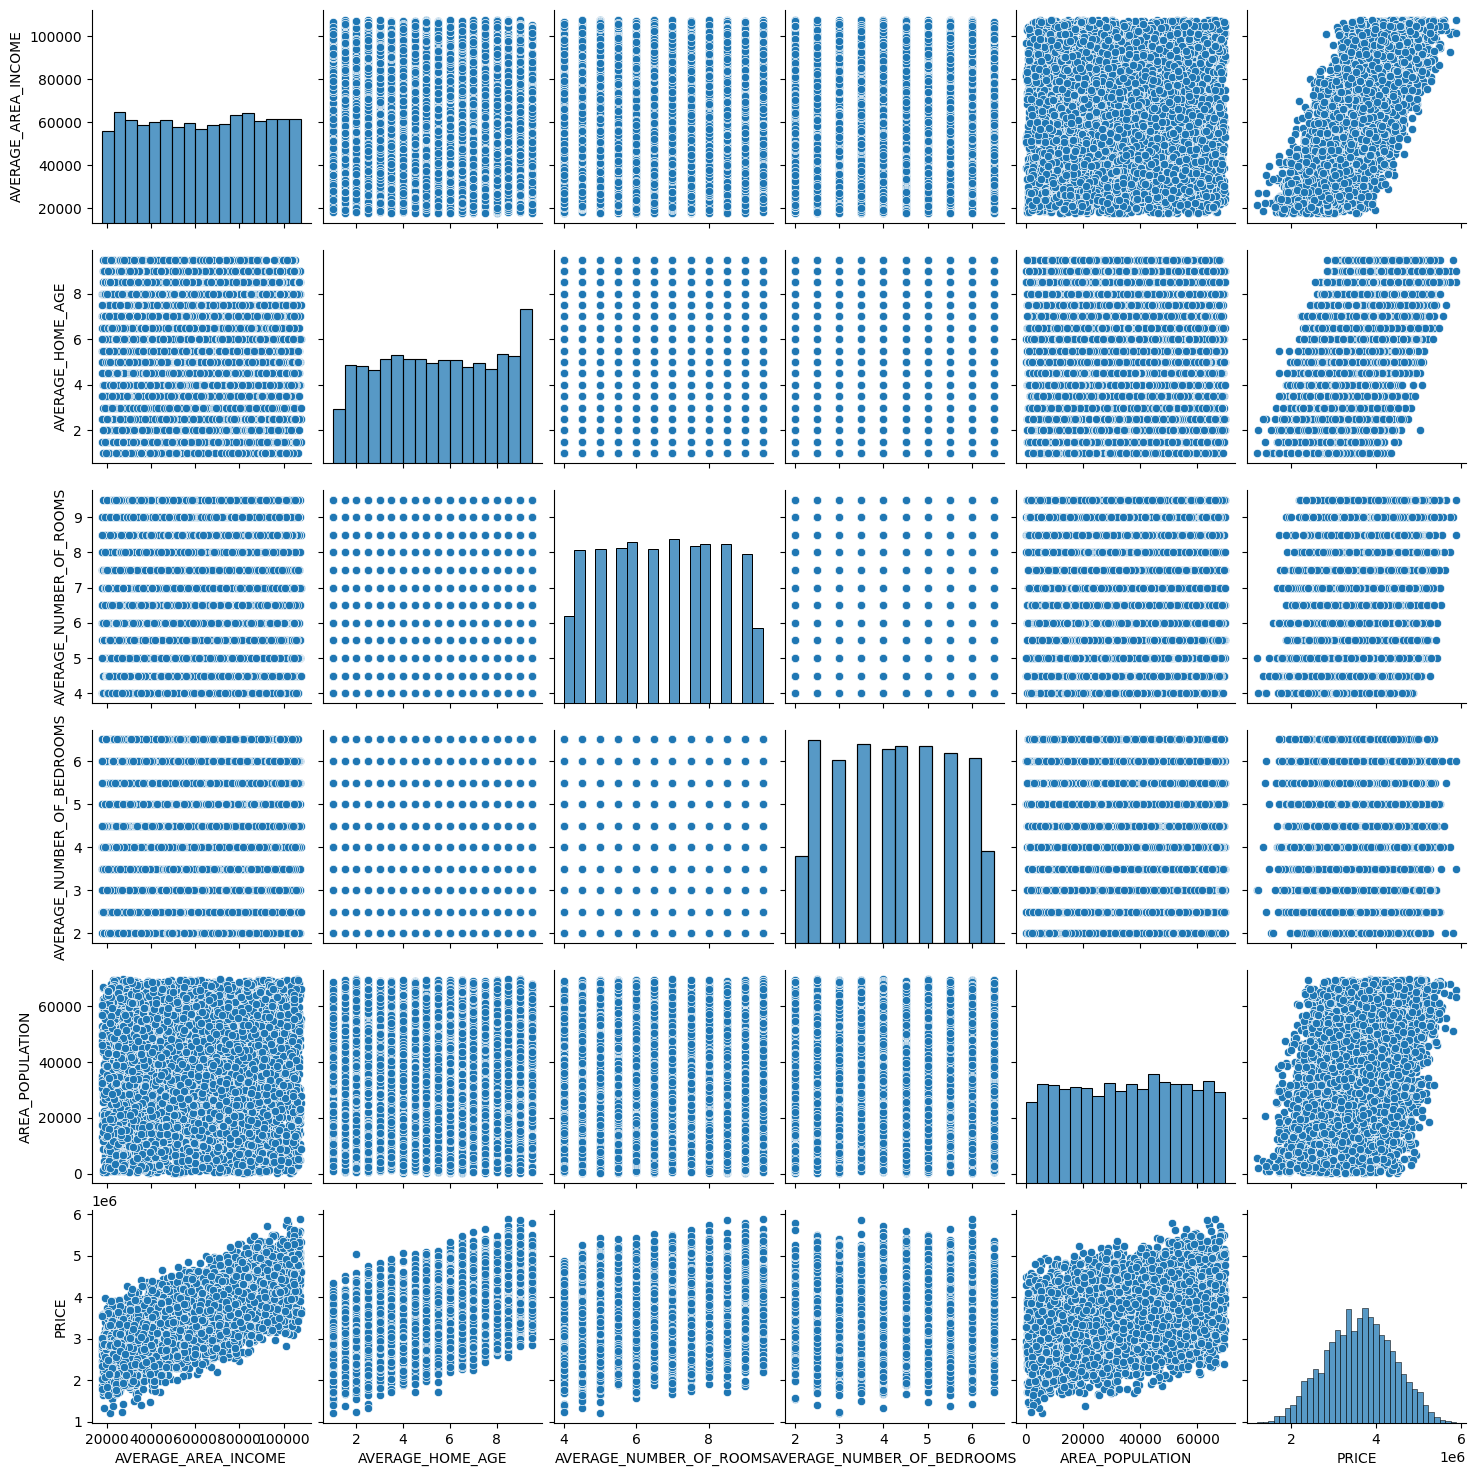

In [14]:
sns.pairplot(housingPDF)

<Axes: xlabel='PRICE', ylabel='Count'>

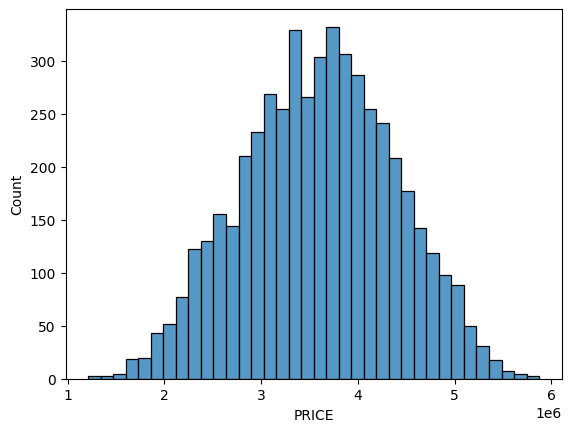

In [15]:
sns.histplot(housingPDF['PRICE'])

<Axes: >

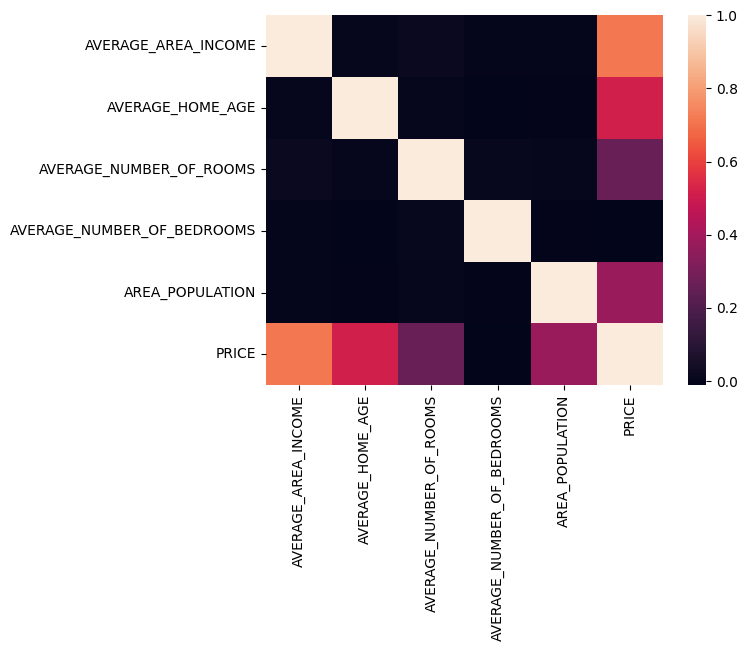

In [ ]:
# sns.heatmap(housingPDF.corr())

# MyNote: numeric_only required to avoid error re non numeric column Address
sns.heatmap(housingPDF.corr(numeric_only=True))


*Interpretation:* Of the available features, AVERAGE_AREA_INCOME shows the highest correlation with PRICE. For an initial model, use that feature alone.

* Using Snowflake, compute the correlation between area income and price.

In [18]:
housingDF.stat.corr('average_area_income', 'price')

0.7131847449261429

- Using Python, plot the two variables

<Axes: xlabel='AVERAGE_AREA_INCOME', ylabel='PRICE'>

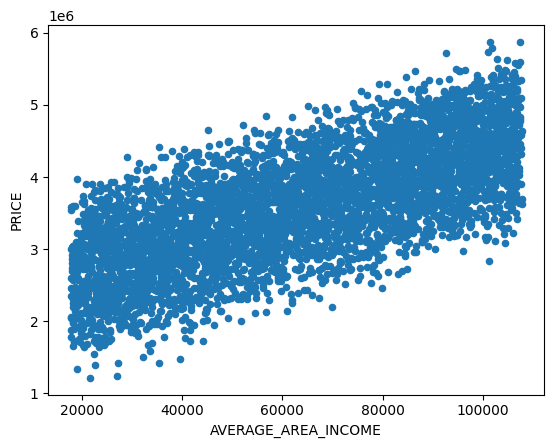

In [19]:
(   housingDF
    .select('AVERAGE_AREA_INCOME', 'PRICE')
    .toPandas()
    .plot.scatter(x='AVERAGE_AREA_INCOME', y='PRICE')
)

### Prepare Data for Regression

In [ ]:
session.sql("USE DATABASE DATA_SCIENCE_DB").collect() # I had to add this, else get error below that db not set


# Select only the feature column and the target
housingDF = housingDF.select('average_area_income', 'price')

# Create train and test sets
(housing_trainDF, housing_testDF) = housingDF.random_split([0.8, 0.2], seed=42)

# Get train and test set sizes
(housing_trainDF.count(), housing_testDF.count())

(3962, 1038)

- Get Pandas DataFrames for training in Scikit-Learn

In [25]:
train_x_PDF = housing_trainDF.drop('price').toPandas()
train_y_PDF = housing_trainDF.select('price').toPandas()

### Train and Examine Linear Model
- Fit the model to the training data

In [26]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(train_x_PDF, train_y_PDF)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


- Examine the model parameters

In [27]:
print('Model intercept: ', lin_reg.intercept_[0])

Model intercept:  2224217.058008551


In [28]:
print('Model coefficent: ', lin_reg.coef_[0][0])

Model coefficent:  21.566488814556287


### Evaluate the Model
- Predict results for the test set

In [29]:
# Fetch test data as Pandas DataFrames
test_x_PDF = housing_testDF.drop('price').toPandas()
test_y_PDF = housing_testDF.select('price').toPandas()

# Run predictions
predictions = lin_reg.predict(test_x_PDF)

- Display a few predictions

In [30]:
import pandas as pd
predictions_PDF = pd.DataFrame(predictions, columns=['prediction'])
test_y_PDF.join(predictions_PDF)[:5]

,PRICE,prediction
0,4373917.93,4.033987e+06
1,4362049.94,4.157782e+06
2,4241004.00,4.252125e+06
3,4007122.86,3.600024e+06
4,3695170.92,3.010685e+06


- Calculate evaluation metrics 

**Record these metrics for comparison with another model.**

In [31]:
from sklearn import metrics
print('r2:\t', metrics.r2_score(test_y_PDF, predictions))

r2:	 0.5197918016170784


In [32]:
import math
print('rmse:\t', round(math.sqrt(metrics.mean_squared_error(test_y_PDF, predictions)), 2))

rmse:	 541863.78


### Examine the Model Visually

- Scatter plot of predictions vs values

Text(0, 0.5, 'Home Price')

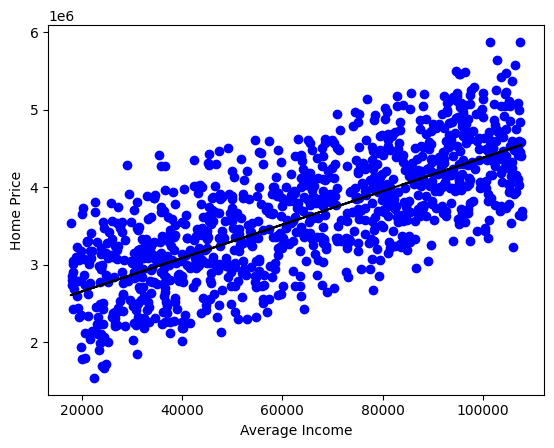

In [33]:
import matplotlib.pyplot as plt
plt.scatter(test_x_PDF, test_y_PDF, color='blue')
plt.plot(test_x_PDF, predictions, color='black')
plt.xlabel('Average Income')
plt.ylabel('Home Price')

- Distribution of prediction errors

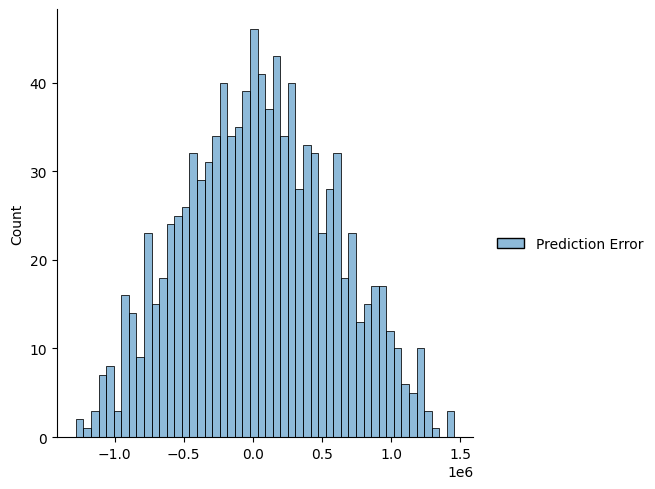

In [34]:
prediction_errors = test_y_PDF - predictions
prediction_errors = prediction_errors.rename(columns={"PRICE" : "Prediction Error"})
sns.displot(prediction_errors, bins=50)